In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

In [19]:
import seaborn as sns

df = sns.load_dataset('tips')

In [20]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [21]:
# Statistical Summary

df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [22]:
# Missing Values

df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

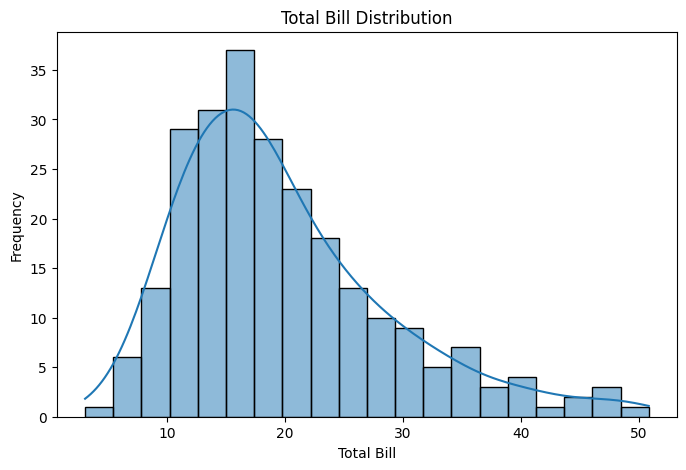

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['total_bill'], bins=20, kde=True)

plt.title("Total Bill Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.show()

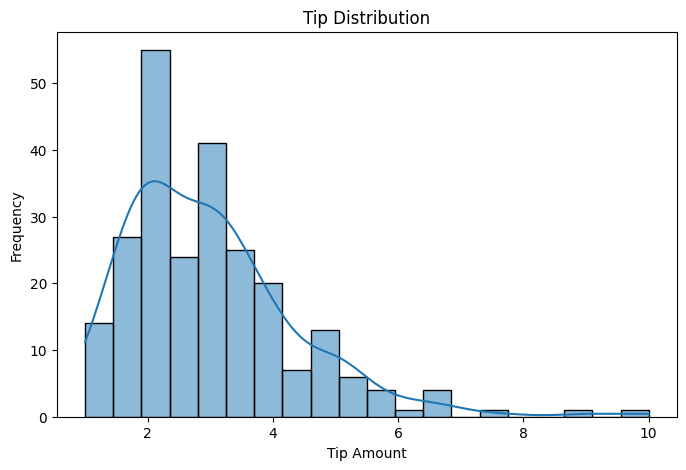

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['tip'], bins=20, kde=True)

plt.title("Tip Distribution")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")

plt.show()

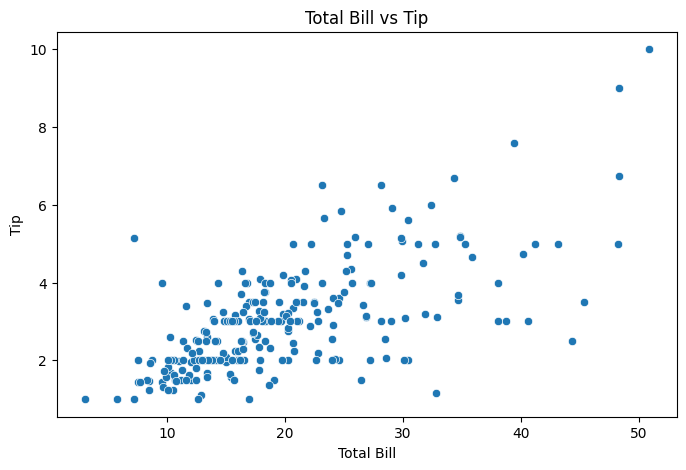

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='total_bill',
    y='tip',
    data=df
)

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

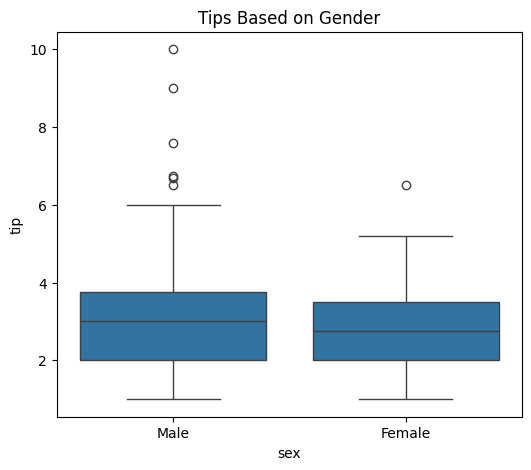

In [26]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='sex',
    y='tip',
    data=df
)

plt.title("Tips Based on Gender")

plt.show()

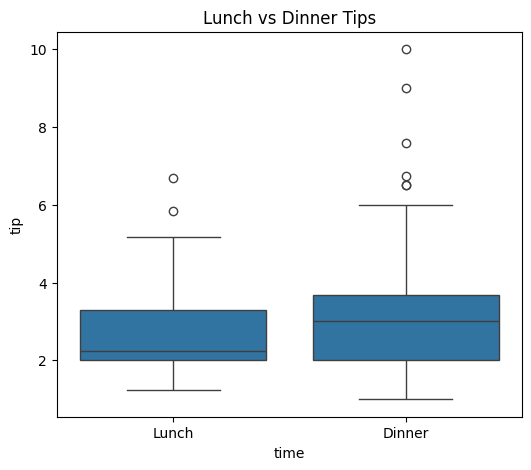

In [27]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='time',
    y='tip',
    data=df
)

plt.title("Lunch vs Dinner Tips")

plt.show()

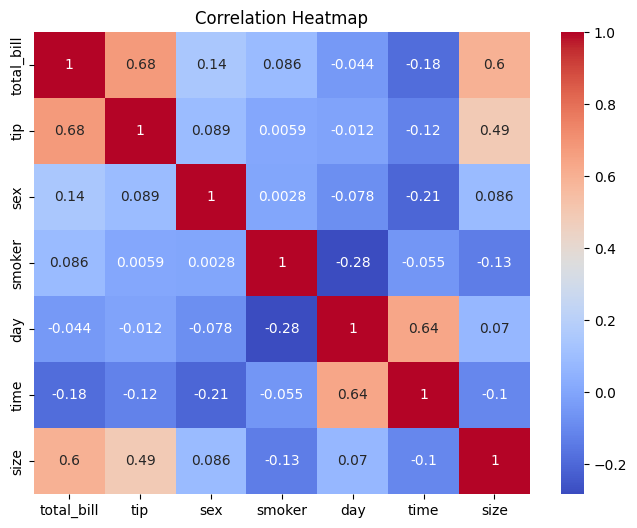

In [44]:
# Temporary Encoding

temp_df = df.copy()

encoder = LabelEncoder()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = encoder.fit_transform(temp_df[col])

plt.figure(figsize=(8,6))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
# Encode Categorical Columns

encoder = LabelEncoder()

categorical_columns = ['sex', 'smoker', 'day', 'time']

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [30]:
# Features and Target

X = df.drop('tip', axis=1)

y = df['tip']

In [31]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
# Initialize Model

model = LinearRegression()

# Train Model

model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# Predictions

y_pred = model.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 0.6703807496461157


In [36]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 0.6948129686287711


In [37]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error :", rmse)



Root Mean Squared Error : 0.8335544185167343


In [38]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.4441368826121931


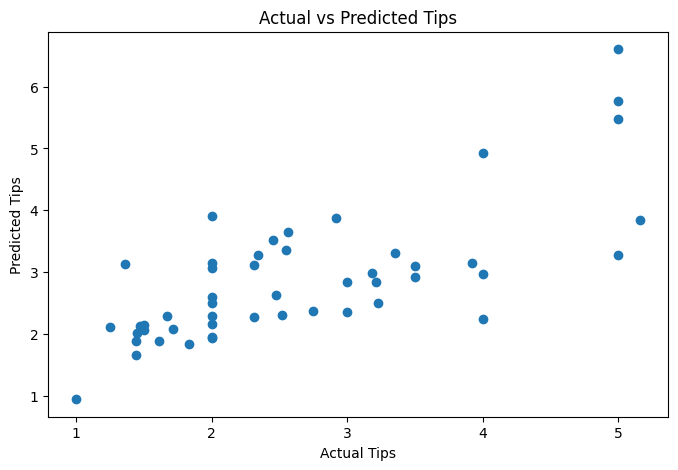

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")

plt.title("Actual vs Predicted Tips")

plt.show()

In [40]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,total_bill,0.093965
1,sex,0.032710
2,smoker,-0.191744
3,day,-0.006830
4,time,0.061226
5,size,0.240303


In [41]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,total_bill,0.093965
1,sex,0.032710
2,smoker,-0.191744
3,day,-0.006830
4,time,0.061226
5,size,0.240303


In [42]:
correlation, p_value = pearsonr(
    df['total_bill'],
    df['tip']
)

print("Correlation Coefficient :", correlation)
print("P-value :", p_value)

Correlation Coefficient : 0.6757341092113647
P-value : 6.6924706468631854e-34


In [43]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a significant relationship between total bill and tip.")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis
There is a significant relationship between total bill and tip.
